In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

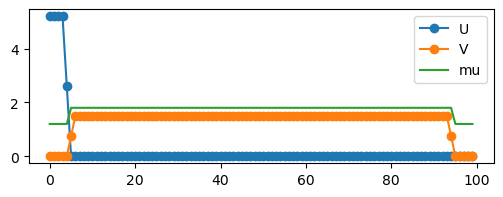

In [6]:
widthS = 5
widthP = 90
widthN = 5
X, Y = widthS+widthP+widthN, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 1.2 * t
muP = 1.8 * t
muN = 1.2 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthN:widthN+widthP] = muP
mu[widthN+widthP:] = muN

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthN:] = 0
U[widthN-1] = U0/2

V0 = 1.5 * t
V = np.zeros(lattice.X)
V[widthS:widthS+widthP] = V0 
V[-widthN-1] = V0/2 
V[widthS] = V0/2 

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

In [7]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.01, -0.01, 0.01j, -0.01j], 
                F0_init=0.1)

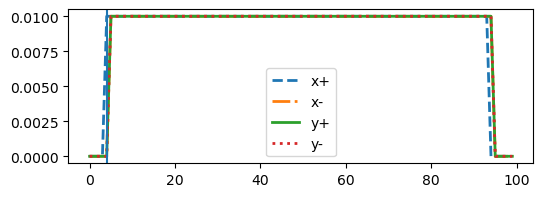

In [8]:
plt.figure(figsize=(6,2))
if U is not None:
    # plt.plot(H.F0, label="F0")
# if V is not None:
#     plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
#     plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
#     plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
#     plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
# if V_prime is not None:
    plt.plot(np.abs(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.abs(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.abs(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.abs(H.F_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [10]:
bdg_sc(H, atol=1e-3, rtol=1e-1, maxiter=100, verbose=True, temperature=T)
F, Fuu, Fdd = H.get_correlations()
F0 = H.F0

F0:
Absolute error: 5.946726935315405e-07
Relative error: 0.00035104233159935624
Average old: (0.02117161080991919+0j)
Average: (0.021171636563387324+0j)
F_xplus:
Absolute error: 4.7969608469504045e-06
Relative error: 0.00041389132616258403
Average old: (0.011342835846260968+0j)
Average: (0.011343217852672683+0j)
F_xmin:
Absolute error: 5.297206187027672e-06
Relative error: 0.00047240264788281697
Average old: (-0.01790445625594083+0j)
Average: (-0.017904922244070046+0j)
F_yplus:
Absolute error: 6.023462216428731e-06
Relative error: 0.0004690744490990118
Average old: (-0.004956325557184528+0.01304639806245718j)
Average: (-0.004956314650674739+0.013045918043724226j)
F_ymin:
Absolute error: 6.023462216428731e-06
Relative error: 0.0004690744490990118
Average old: (-0.004956325557184528-0.01304639806245718j)
Average: (-0.004956314650674739-0.013045918043724226j)
Fuu_xplus:
Absolute error: 5.52242876975979e-17
Relative error: 5.5224348656508096e-05
Average old: (1.9810269470224156e-19+0j)
Av

T=0.001t


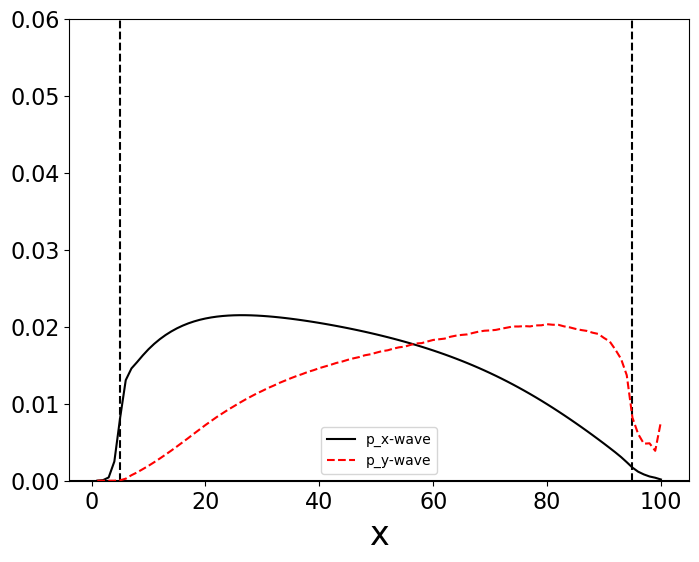

[3.87905602e-01 3.69072796e-01 3.67420843e-01 3.54080110e-01
 1.98247987e-01 6.32895542e-02 4.28445750e-02 3.33628144e-02
 2.75647193e-02 2.40788783e-02 2.06696908e-02 1.88786219e-02
 1.64597480e-02 1.53233359e-02 1.34781405e-02 1.26077918e-02
 1.11577071e-02 1.03995078e-02 9.26619737e-03 8.59277549e-03
 7.75317565e-03 7.17992698e-03 6.58587477e-03 6.08072529e-03
 5.62362080e-03 5.12954963e-03 4.74747215e-03 4.30262940e-03
 4.02999301e-03 3.67831953e-03 3.47175255e-03 3.14314192e-03
 2.93806828e-03 2.64895020e-03 2.50398227e-03 2.28554262e-03
 2.16245460e-03 1.95878941e-03 1.85216606e-03 1.69809080e-03
 1.61119983e-03 1.47097826e-03 1.38113259e-03 1.28175858e-03
 1.20494075e-03 1.12768277e-03 1.04249551e-03 1.00361977e-03
 9.08798613e-04 8.91216660e-04 7.87798776e-04 8.09463041e-04
 6.88883270e-04 7.34426557e-04 6.14870043e-04 6.64027823e-04
 5.51031023e-04 6.05565770e-04 5.06271601e-04 5.47609814e-04
 4.81931489e-04 4.85600097e-04 4.73207344e-04 4.27267771e-04
 4.73998504e-04 3.754216

In [16]:
print(f"T={T}t")
x = np.arange(1, widthN + widthP + widthS+1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.axhline(0, color = 'black')
axs.axvline(widthS+widthP, color='black', linestyle='--')
axs.axvline(widthS, color='black', linestyle='--')
# axs.plot(x, np.real(F0), label='onsite')
# axs.plot(x, np.real(F.swave), color='green', label="s-wave")
# axs.plot(x, np.real(F.dwave), color='blue', label="d-wave")
# axs.plot(x, np.real(Fuu.px), color='orange', label="uu:p_x-wave")
axs.plot(x, np.real(F.px), color='black', label="p_x-wave")
axs.plot(x, np.imag(F.py), "--", color='red', label="p_y-wave")

axs.set_xlabel(r"x", fontsize=24)
# axs.set_yticks([])
# axs.set_xlim(1, 50)
axs.set_ylim(0, 0.06)
axs.tick_params(labelsize=16)
plt.legend()
plt.savefig('../figures/SP.svg')
plt.show()
print(np.real(F0))

In [7]:
T_list = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.20 + 1e-12, 0.001),
]) #
print(len(T_list))

200
